# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

sample image shape:  (400, 600, 3)


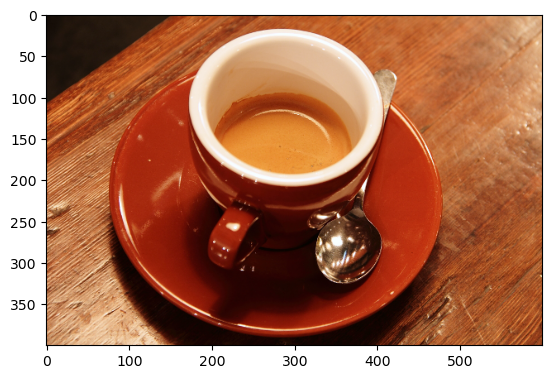

In [2]:
sample_image = skimage.data.coffee()

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8'));

### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [3]:
from tensorflow.keras.layers import Conv2D

In [4]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [5]:
sample_image.shape

(400, 600, 3)

In [6]:
img_in = np.expand_dims(sample_image, 0).astype(float)
img_in.shape

(1, 400, 600, 3)

In [7]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [8]:
np_img_out = img_out[0].numpy()
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


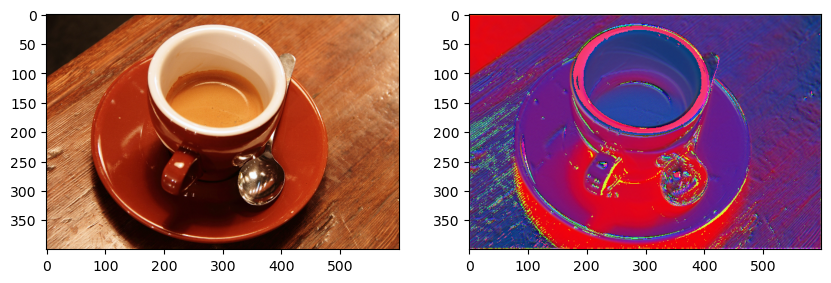

In [9]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8'))
ax1.imshow(np_img_out.astype('uint8'));

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [10]:
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 25
    array[:, :, 1, 1] = 1 / 25
    array[:, :, 2, 2] = 1 / 25
    return array

Now we can use this function to initialize a `Conv2D` layer:

In [11]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)

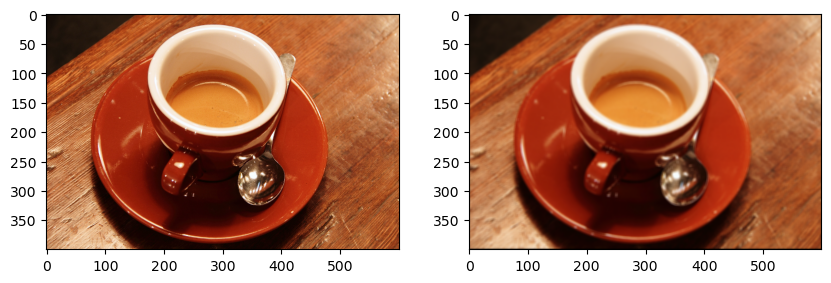

In [12]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

Testing different kernel sizes...


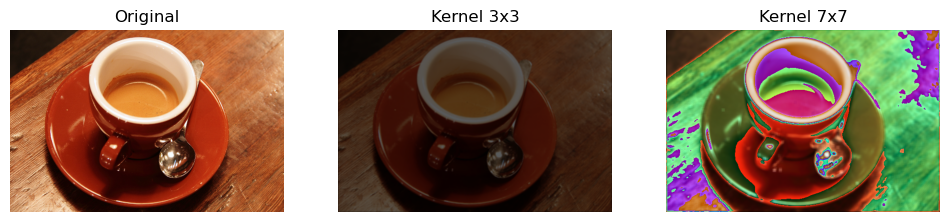


Testing 'same' vs 'valid' padding...


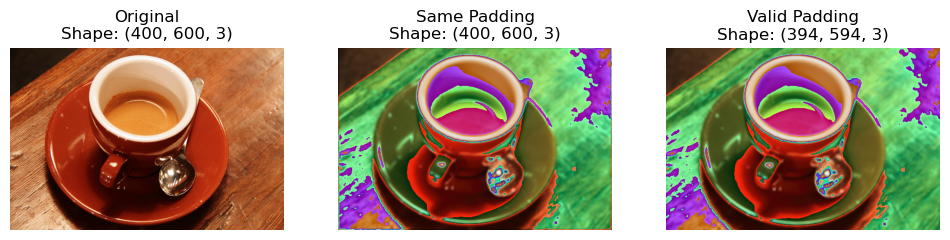

Original: (400, 600, 3)
Same padding: (400, 600, 3) (same size)
Valid padding: (394, 594, 3) (smaller size)


In [13]:
# Simple experiments with Conv2D parameters

# Test different kernel sizes
print("Testing different kernel sizes...")
kernel_sizes = [3, 7]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Show original
axes[0].imshow(img_in[0].astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

# Test each kernel size
for i, size in enumerate(kernel_sizes):
    conv = Conv2D(filters=3, kernel_size=(size, size), padding="same", kernel_initializer=my_kernel)
    img_out = conv(img_in)
    np_img_out = img_out[0].numpy()
    
    axes[i+1].imshow(np_img_out.astype('uint8'))
    axes[i+1].set_title(f'Kernel {size}x{size}')
    axes[i+1].axis('off')

plt.show()

# Test different padding
print("\nTesting 'same' vs 'valid' padding...")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].imshow(img_in[0].astype('uint8'))
axes[0].set_title(f'Original\nShape: {img_in[0].shape}')
axes[0].axis('off')

# Same padding
conv_same = Conv2D(filters=3, kernel_size=(7, 7), padding="same", kernel_initializer=my_kernel)
img_same = conv_same(img_in)
np_img_same = img_same[0].numpy()

axes[1].imshow(np_img_same.astype('uint8'))
axes[1].set_title(f'Same Padding\nShape: {np_img_same.shape}')
axes[1].axis('off')

# Valid padding
conv_valid = Conv2D(filters=3, kernel_size=(7, 7), padding="valid", kernel_initializer=my_kernel)
img_valid = conv_valid(img_in)
np_img_valid = img_valid[0].numpy()

axes[2].imshow(np_img_valid.astype('uint8'))
axes[2].set_title(f'Valid Padding\nShape: {np_img_valid.shape}')
axes[2].axis('off')

plt.show()

print(f"Original: {img_in[0].shape}")
print(f"Same padding: {np_img_same.shape} (same size)")
print(f"Valid padding: {np_img_valid.shape} (smaller size)")

### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

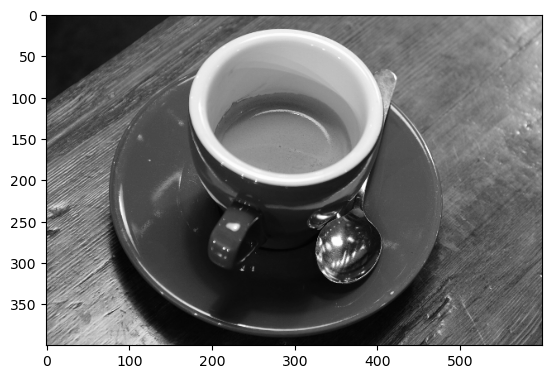

In [14]:
# convert image to greyscale
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

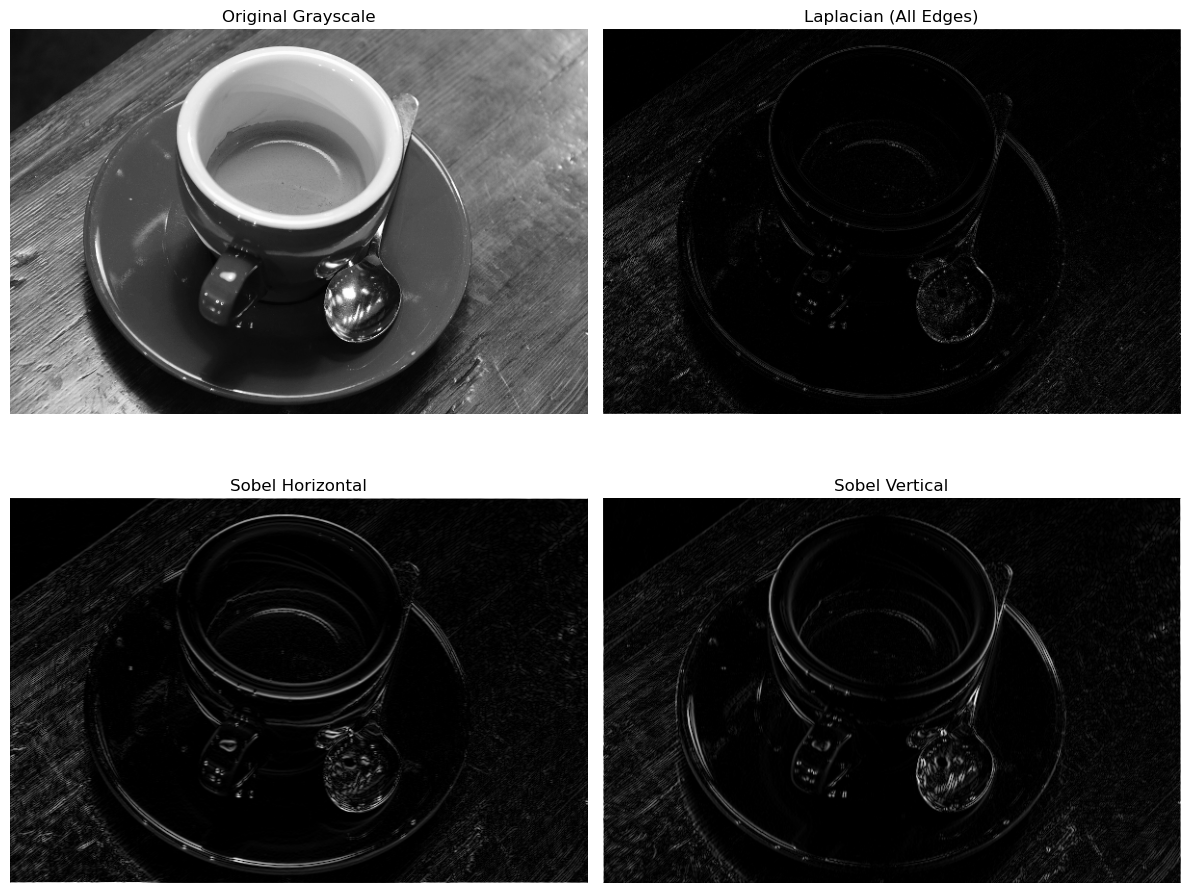

Edge Detection Results:
• Laplacian: Detects edges in all directions
• Sobel Horizontal: Detects horizontal edges (vertical lines)
• Sobel Vertical: Detects vertical edges (horizontal lines)


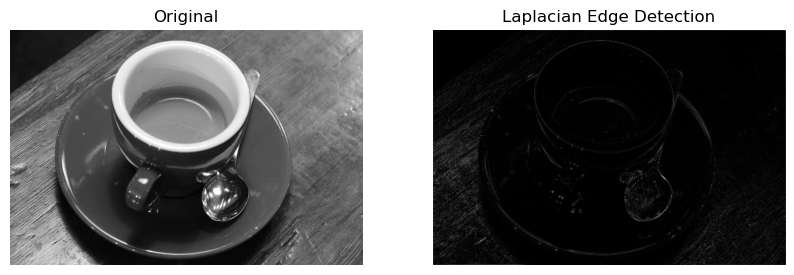

In [15]:
# Edge Detection Kernels - Try different ones!

# 1. Simple Edge Detection (Laplacian)
def laplacian_kernel(shape=(3, 3, 1, 1), dtype=None):
    array = np.array([[ 0, -1,  0],
                      [-1,  4, -1],
                      [ 0, -1,  0]], dtype="float32")
    array = array.reshape(*shape)
    return array

# 2. Sobel Edge Detection (horizontal edges)
def sobel_horizontal_kernel(shape=(3, 3, 1, 1), dtype=None):
    array = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype="float32")
    array = array.reshape(*shape)
    return array

# 3. Sobel Edge Detection (vertical edges)
def sobel_vertical_kernel(shape=(3, 3, 1, 1), dtype=None):
    array = np.array([[-1,  0,  1],
                      [-2,  0,  2],
                      [-1,  0,  1]], dtype="float32")
    array = array.reshape(*shape)
    return array

# Test different edge detection kernels
kernels = [
    ("Laplacian (All Edges)", laplacian_kernel),
    ("Sobel Horizontal", sobel_horizontal_kernel),
    ("Sobel Vertical", sobel_vertical_kernel)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Show original image
img_in = np.expand_dims(grey_sample_image, 0)
axes[0, 0].imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
axes[0, 0].set_title('Original Grayscale')
axes[0, 0].axis('off')

# Apply each kernel
for i, (name, kernel_func) in enumerate(kernels):
    row = (i + 1) // 2
    col = (i + 1) % 2
    
    conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=kernel_func)
    img_out = conv(img_in)
    np_img_out = img_out[0].numpy()
    
    # Normalize output for better visualization
    np_img_out = np.abs(np_img_out)  # Take absolute value
    np_img_out = (np_img_out - np_img_out.min()) / (np_img_out.max() - np_img_out.min()) * 255
    
    axes[row, col].imshow(np.squeeze(np_img_out.astype(np.uint8)), cmap=plt.cm.gray)
    axes[row, col].set_title(name)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Edge Detection Results:")
print("• Laplacian: Detects edges in all directions")
print("• Sobel Horizontal: Detects horizontal edges (vertical lines)")
print("• Sobel Vertical: Detects vertical edges (horizontal lines)")

# Let's also try a simple implementation with one kernel for the original exercise
def my_kernel(shape=(3, 3, 1, 1), dtype=None):
    # Using Laplacian kernel for edge detection
    array = np.array([[ 0, -1,  0],
                      [-1,  4, -1],
                      [ 0, -1,  0]], dtype="float32")
    array = array.reshape(*shape)
    return array

# Apply the kernel as in the original exercise format
conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=my_kernel)
img_out = conv(img_in)
np_img_out = img_out[0].numpy()

# Normalize for better visualization
np_img_out = np.abs(np_img_out)
np_img_out = (np_img_out - np_img_out.min()) / (np_img_out.max() - np_img_out.min()) * 255

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title('Original')
ax0.axis('off')

ax1.imshow(np.squeeze(np_img_out.astype(np.uint8)), cmap=plt.cm.gray)
ax1.set_title('Laplacian Edge Detection')
ax1.axis('off')

plt.show()


### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

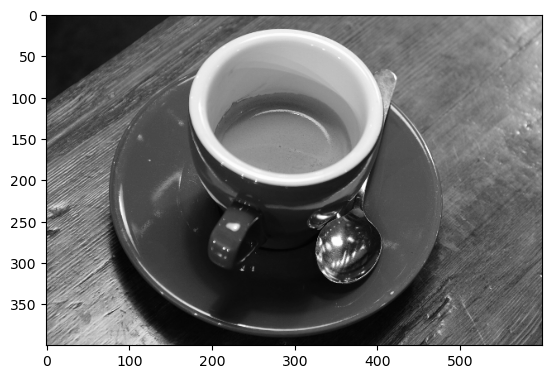

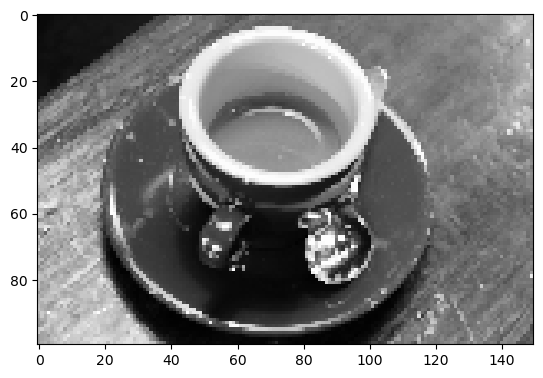

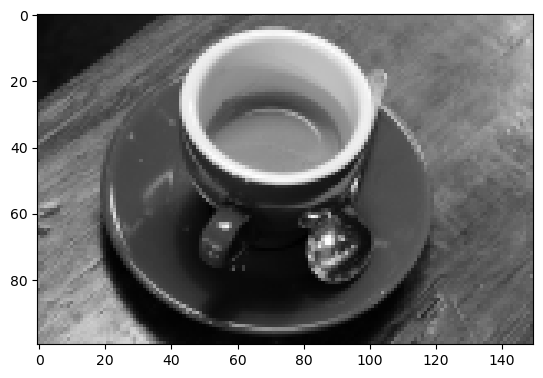

In [16]:
from tensorflow.keras.layers import MaxPool2D, AvgPool2D

# You can use `img_in` from above as input to the pooling layers

plt.figure()
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

pool = MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
              cmap=plt.cm.gray);

pool = AvgPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
                cmap=plt.cm.gray);

## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

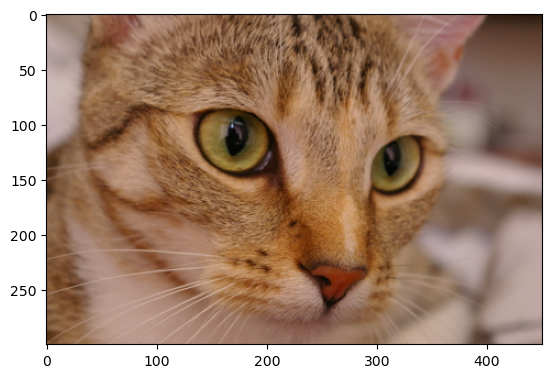

In [17]:
from skimage.io import imread

image = skimage.data.cat()
plt.imshow(image);

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [18]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)
lowres_image.shape

(50, 50, 3)

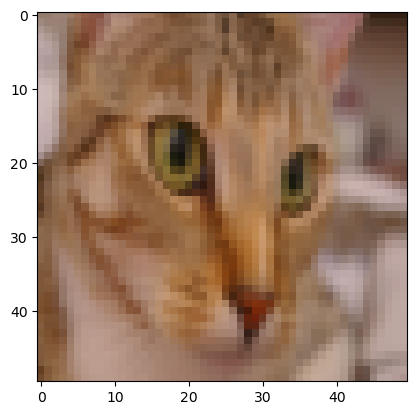

In [19]:
plt.imshow(lowres_image, interpolation='nearest');

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [20]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
model.compile(optimizer='sgd', loss='categorical_crossentropy')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 37s 0us/step


In [21]:
print(model.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

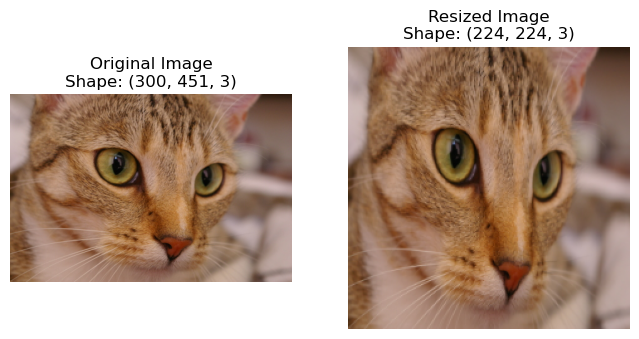

Image shape after adding batch dimension: (1, 224, 224, 3)
Preprocessed image shape: (1, 224, 224, 3)
Preprocessed image range: [-119.68, 86.32]
Making prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
Prediction shape: (1, 1000)
Prediction contains probabilities for 1000 classes
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
Prediction shape: (1, 1000)
Prediction contains probabilities for 1000 classes
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

Top 5 predictions:
1. Egyptian_cat: 0.9551 (95.51%)
2. tiger_cat: 0.0185 (1.85%)
3. tabby: 0.0180 (1.80%)
4. shower_cap: 0.0055 (0.55%)
5. plastic_bag: 0.0011 (0.11%)

Top 5 predictions:
1. Egyptian_cat: 0.9551 (95.51%)
2. tiger_cat: 0.0185 (1.85%)
3. tabby: 0.0180 (1.80%)
4. shower_cap: 0.0055 (0.55%)
5. plastic_bag: 0.0011 (0.11%)


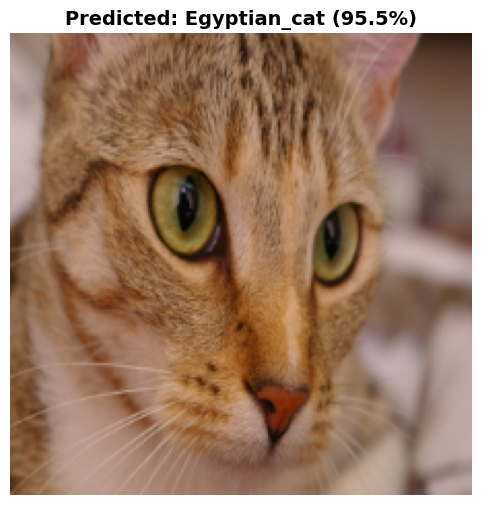

In [22]:
from keras.applications.resnet50 import preprocess_input, decode_predictions

# Step 1: Reshape the cat image to (224, 224, 3)
# ResNet50 expects input images to be 224x224 pixels
resized_image = resize(image, (224, 224), mode='reflect', anti_aliasing=True)

# Display the resized image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f'Original Image\nShape: {image.shape}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title(f'Resized Image\nShape: {resized_image.shape}')
plt.axis('off')
plt.show()

# Step 2: Preprocess the image for ResNet50
# Convert to the format expected by the model (batch dimension + proper scaling)
# First, ensure the image is in the right range (0-255) and data type
if resized_image.max() <= 1.0:
    resized_image = (resized_image * 255).astype(np.uint8)

# Add batch dimension (models expect batches of images)
input_image = np.expand_dims(resized_image, axis=0)
print(f"Image shape after adding batch dimension: {input_image.shape}")

# Apply ResNet50-specific preprocessing
preprocessed_image = preprocess_input(input_image.astype(np.float32))
print(f"Preprocessed image shape: {preprocessed_image.shape}")
print(f"Preprocessed image range: [{preprocessed_image.min():.2f}, {preprocessed_image.max():.2f}]")

# Step 3: Use the model to predict/classify the image
print("Making prediction...")
predictions = model.predict(preprocessed_image)
print(f"Prediction shape: {predictions.shape}")
print(f"Prediction contains probabilities for {predictions.shape[1]} classes")

# Step 4: Decode the predictions to get human-readable class names
# decode_predictions returns the top 5 most likely classes
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("\nTop 5 predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i+1}. {label}: {score:.4f} ({score*100:.2f}%)")

# Display the result nicely
plt.figure(figsize=(8, 6))
plt.imshow(resized_image)
plt.title(f'Predicted: {decoded_predictions[0][1]} ({decoded_predictions[0][2]*100:.1f}%)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

Successfully downloaded image!
Image shape: (1600, 1283, 3)
Image dtype: uint8
Image range: [0, 255]


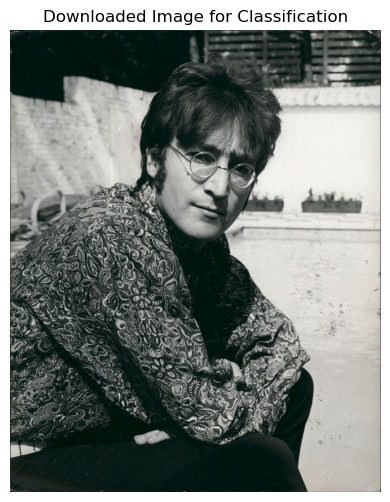

In [25]:
# Using an image from the web instead of webcam
import requests
from PIL import Image
from io import BytesIO

# Download image from URL
url = "https://cdn.britannica.com/27/262227-050-E8D701BC/John-Lennon-The-Beatles-1968.jpg"

try:
    # Download the image
    response = requests.get(url)
    response.raise_for_status()  # Raises an HTTPError for bad responses
    
    # Convert to PIL Image and then to numpy array
    pil_image = Image.open(BytesIO(response.content))
    # Convert to RGB if necessary (in case it's RGBA or grayscale)
    if pil_image.mode != 'RGB':
        pil_image = pil_image.convert('RGB')
    
    # Convert PIL image to numpy array
    web_image = np.array(pil_image)
    
    print(f"Successfully downloaded image!")
    print(f"Image shape: {web_image.shape}")
    print(f"Image dtype: {web_image.dtype}")
    print(f"Image range: [{web_image.min()}, {web_image.max()}]")
    
    # Display the downloaded image
    plt.figure(figsize=(8, 6))
    plt.imshow(web_image)
    plt.title('Downloaded Image for Classification')
    plt.axis('off')
    plt.show()
    
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")
    print("Using a fallback image (cat) instead...")
    # Fallback to the cat image we used earlier
    web_image = skimage.data.cat()
    
except Exception as e:
    print(f"Error processing image: {e}")
    print("Using a fallback image (cat) instead...")
    # Fallback to the cat image we used earlier
    web_image = skimage.data.cat()

### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

Preprocessed image shape: (1, 224, 224, 3)
Preprocessed image range: [-123.68, 136.06]

Making prediction on downloaded image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

Top 5 predictions for downloaded image:
1. kimono: 0.1657 (16.57%)
2. fur_coat: 0.1543 (15.43%)
3. tricycle: 0.0990 (9.90%)
4. stole: 0.0516 (5.16%)
5. trench_coat: 0.0425 (4.25%)

Top 5 predictions for downloaded image:
1. kimono: 0.1657 (16.57%)
2. fur_coat: 0.1543 (15.43%)
3. tricycle: 0.0990 (9.90%)
4. stole: 0.0516 (5.16%)
5. trench_coat: 0.0425 (4.25%)


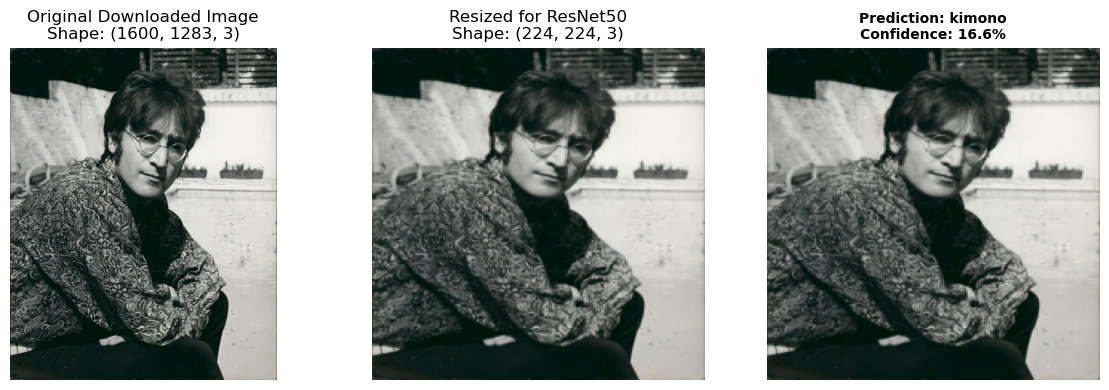


COMPARISON SUMMARY:
Cat image prediction: Egyptian_cat (95.5%)
Downloaded image prediction: kimono (16.6%)


In [26]:
# Apply the same preprocessing as before and classify the downloaded image

# Step 1: Reshape the image to (224, 224, 3) for ResNet50
resized_web_image = resize(web_image, (224, 224), mode='reflect', anti_aliasing=True)

# Display comparison
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(web_image)
plt.title(f'Original Downloaded Image\nShape: {web_image.shape}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(resized_web_image)
plt.title(f'Resized for ResNet50\nShape: {resized_web_image.shape}')
plt.axis('off')

# Step 2: Preprocess the image for ResNet50
# Ensure proper data type and range
if resized_web_image.max() <= 1.0:
    resized_web_image = (resized_web_image * 255).astype(np.uint8)

# Add batch dimension
input_web_image = np.expand_dims(resized_web_image, axis=0)

# Apply ResNet50-specific preprocessing
preprocessed_web_image = preprocess_input(input_web_image.astype(np.float32))

print(f"Preprocessed image shape: {preprocessed_web_image.shape}")
print(f"Preprocessed image range: [{preprocessed_web_image.min():.2f}, {preprocessed_web_image.max():.2f}]")

# Step 3: Make prediction
print("\nMaking prediction on downloaded image...")
web_predictions = model.predict(preprocessed_web_image)

# Step 4: Decode predictions
web_decoded_predictions = decode_predictions(web_predictions, top=5)[0]

print("\nTop 5 predictions for downloaded image:")
for i, (imagenet_id, label, score) in enumerate(web_decoded_predictions):
    print(f"{i+1}. {label}: {score:.4f} ({score*100:.2f}%)")

# Display final result
plt.subplot(1, 3, 3)
plt.imshow(resized_web_image)
plt.title(f'Prediction: {web_decoded_predictions[0][1]}\nConfidence: {web_decoded_predictions[0][2]*100:.1f}%', 
          fontsize=10, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

# Compare with the cat image results
print(f"\n{'='*50}")
print("COMPARISON SUMMARY:")
print(f"{'='*50}")
try:
    print(f"Cat image prediction: {decoded_predictions[0][1]} ({decoded_predictions[0][2]*100:.1f}%)")
except:
    print("Cat image: Not classified yet")
print(f"Downloaded image prediction: {web_decoded_predictions[0][1]} ({web_decoded_predictions[0][2]*100:.1f}%)")
print(f"{'='*50}")